# 3D Print Failure Prediction — Geometry Feature Integration
**Cornell Tech MakerLAB Project**

Closes the generalization gap identified in notebook 05 by adding 16 G-code geometry features
to the 20 slicer-setting features. Retrains LR and NN on the 55-sample real-world labeled dataset
using 5-fold cross-validation, then compares against the settings-only real-world baseline (AUC≈0.56).

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import json
import pickle
import matplotlib.pyplot as plt
from src.preprocessing import preprocess_single, apply_scaler
from src.logistic_regression import LogisticRegression
from src.neural_network import NeuralNetwork

DATA_DIR   = "../data/raw/processed"
MODELS_DIR = "../models"
CSV_PATH   = "../data/raw/real_world_data_labeling_sheet.csv"
GEO_PATH   = "../data/raw/geometry_features.csv"

## 1. Load artifacts and datasets

In [2]:
with open(f"{DATA_DIR}/scaler_params.json") as f: scaler = json.load(f)
with open(f"{DATA_DIR}/feature_cols.json")  as f: feature_cols = json.load(f)
with open(f"{DATA_DIR}/ohe_cols.json")       as f: ohe_map = json.load(f)

SLICER_COLS = [
    "nozzle_temperature", "nozzle_temperature_initial_layer",
    "layer_height", "initial_layer_print_height",
    "inner_wall_speed", "outer_wall_speed", "bridge_speed",
    "fan_max_speed", "sparse_infill_density", "bottom_shell_layers",
    "top_shell_layers", "wall_loops", "retraction_length",
    "retraction_speed", "enable_support", "filament_type"
]

GEO_COLS = [
    "total_layers", "max_z_height_mm", "total_toolpath_mm",
    "extrusion_travel_ratio", "est_print_duration_sec", "path_variability",
    "bbox_x_mm", "bbox_y_mm", "aspect_ratio",
    "first_layer_toolpath_mm", "max_layer_toolpath_mm", "sparse_layer_fraction",
    "avg_feedrate_mms", "feedrate_cv", "retraction_count", "retraction_density"
]

# Load and merge
labels = pd.read_csv(CSV_PATH).dropna(subset=["print_outcome"]).copy()
labels["print_outcome"] = labels["print_outcome"].astype(int)

geo = pd.read_csv(GEO_PATH).rename(columns={"filename": "gcode_filename"})
df  = labels.merge(geo, on="gcode_filename", how="inner").reset_index(drop=True)

# Invert label to match model convention: 1=failure, 0=success
df["label"] = 1 - df["print_outcome"]

print(f"Combined dataset: {df.shape[0]} rows × {len(SLICER_COLS) + len(GEO_COLS)} input features")
print(f"Class dist — failure(1): {(df['label']==1).sum()} | success(0): {(df['label']==0).sum()}")

Combined dataset: 55 rows × 32 input features
Class dist — failure(1): 21 | success(0): 34


## 2. Build full feature matrix

Slicer features: preprocessed with the existing training scaler and OHE (no re-fitting — same transform as training).  
Geometry features: min-max scaled independently within each CV fold to avoid leakage.

In [3]:
# Slicer features — use existing training artifacts
X_slicer_list = []
for _, row in df.iterrows():
    raw = {col: row[col] for col in SLICER_COLS}
    X_slicer_list.append(preprocess_single(raw, feature_cols, scaler, ohe_map)[0])
X_slicer = np.vstack(X_slicer_list).astype(np.float32)  # (55, 20)

# Geometry features — raw values, will be scaled per fold
X_geo_raw = df[GEO_COLS].values.astype(np.float32)       # (55, 16)

y = df["label"].values.astype(np.float32)

print("Slicer features:",  X_slicer.shape)
print("Geometry features:", X_geo_raw.shape)
print("Labels:", y.shape)

Slicer features: (55, 20)
Geometry features: (55, 16)
Labels: (55,)


## 3. Helper functions — metrics and geometry scaler

In [4]:
def scale_geo(X_train, X_test):
    """Min-max scale geometry features fitted on train fold only."""
    col_min = X_train.min(axis=0)
    col_max = X_train.max(axis=0)
    rng = np.where(col_max - col_min == 0, 1.0, col_max - col_min)
    return (X_train - col_min) / rng, np.clip((X_test - col_min) / rng, 0, 1)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tp = ((y_pred==1) & (y_true==1)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()
    tn = ((y_pred==0) & (y_true==0)).sum()
    acc  = (y_pred == y_true).mean()
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    # AUC
    thresholds = np.linspace(0, 1, 201)
    tprs, fprs = [], []
    for t in thresholds:
        p  = (y_prob >= t).astype(int)
        _tp = np.sum((p==1) & (y_true==1)); _fn = np.sum((p==0) & (y_true==1))
        _fp = np.sum((p==1) & (y_true==0)); _tn = np.sum((p==0) & (y_true==0))
        tprs.append(_tp / (_tp + _fn + 1e-12))
        fprs.append(_fp / (_fp + _tn + 1e-12))
    auc = float(-np.trapezoid(tprs, fprs))
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc)

## 4. 5-Fold Cross-Validation — three feature sets

We compare three configurations head-to-head:
- **A** — Slicer settings only (20 features) — baseline matching notebook 05
- **B** — Geometry features only (16 features)
- **C** — Slicer + Geometry combined (36 features) — full model

In [5]:
np.random.seed(42)
n = len(y)
indices = np.random.permutation(n)
folds = np.array_split(indices, 5)

configs = {
    "A_slicer_only":    {"use_slicer": True,  "use_geo": False},
    "B_geometry_only":  {"use_slicer": False, "use_geo": True},
    "C_combined":       {"use_slicer": True,  "use_geo": True},
}

results = {name: {"lr": [], "nn": []} for name in configs}

for fold_i, test_idx in enumerate(folds):
    train_idx = np.concatenate([folds[j] for j in range(5) if j != fold_i])

    for config_name, cfg in configs.items():
        # Build feature matrices
        parts_train, parts_test = [], []

        if cfg["use_slicer"]:
            parts_train.append(X_slicer[train_idx])
            parts_test.append(X_slicer[test_idx])

        if cfg["use_geo"]:
            geo_tr, geo_te = scale_geo(X_geo_raw[train_idx], X_geo_raw[test_idx])
            parts_train.append(geo_tr)
            parts_test.append(geo_te)

        X_tr = np.hstack(parts_train).astype(np.float32)
        X_te = np.hstack(parts_test).astype(np.float32)
        y_tr = y[train_idx]
        y_te = y[test_idx]

        # Logistic Regression
        lr = LogisticRegression(lr=0.001, n_iter=2000)
        lr.fit(X_tr, y_tr, class_weight="balanced")
        lr_prob = lr.predict_proba(X_te)
        results[config_name]["lr"].append(compute_metrics(y_te, lr_prob))

        # Neural Network
        nn = NeuralNetwork(hidden_layers=(32, 16), lr=0.01, n_iter=1000, l2=0.001, random_state=42)
        nn.fit(X_tr, y_tr, class_weight="balanced")
        nn_prob = nn.predict_proba(X_te)
        results[config_name]["nn"].append(compute_metrics(y_te, nn_prob))

print("Cross-validation complete.")

Cross-validation complete.


## 5. Results — mean CV metrics across all three configurations

In [6]:
def mean_metrics(fold_list):
    keys = fold_list[0].keys()
    return {k: float(np.mean([f[k] for f in fold_list])) for k in keys}


print(f"{'Config':<22} {'Model':<4}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AUC':>6}")
print("-" * 65)

summary = {}
for config_name, models in results.items():
    for model_name, fold_list in models.items():
        m = mean_metrics(fold_list)
        summary[f"{config_name}_{model_name}"] = m
        print(f"{config_name:<22} {model_name:<4}  "
              f"{m['accuracy']:>6.3f}  {m['precision']:>6.3f}  "
              f"{m['recall']:>6.3f}  {m['f1']:>6.3f}  {m['auc']:>6.3f}")

Config                 Model     Acc    Prec     Rec      F1     AUC
-----------------------------------------------------------------
A_slicer_only          lr     0.436   0.399   0.971   0.548   0.537
A_slicer_only          nn     0.564   0.378   0.293   0.285   0.537
B_geometry_only        lr     0.618   0.000   0.000   0.000   0.500
B_geometry_only        nn     0.382   0.150   0.197   0.167   0.358
C_combined             lr     0.673   0.450   0.303   0.328   0.573
C_combined             nn     0.564   0.433   0.586   0.473   0.599


## 6. Before vs After comparison — settings-only vs combined

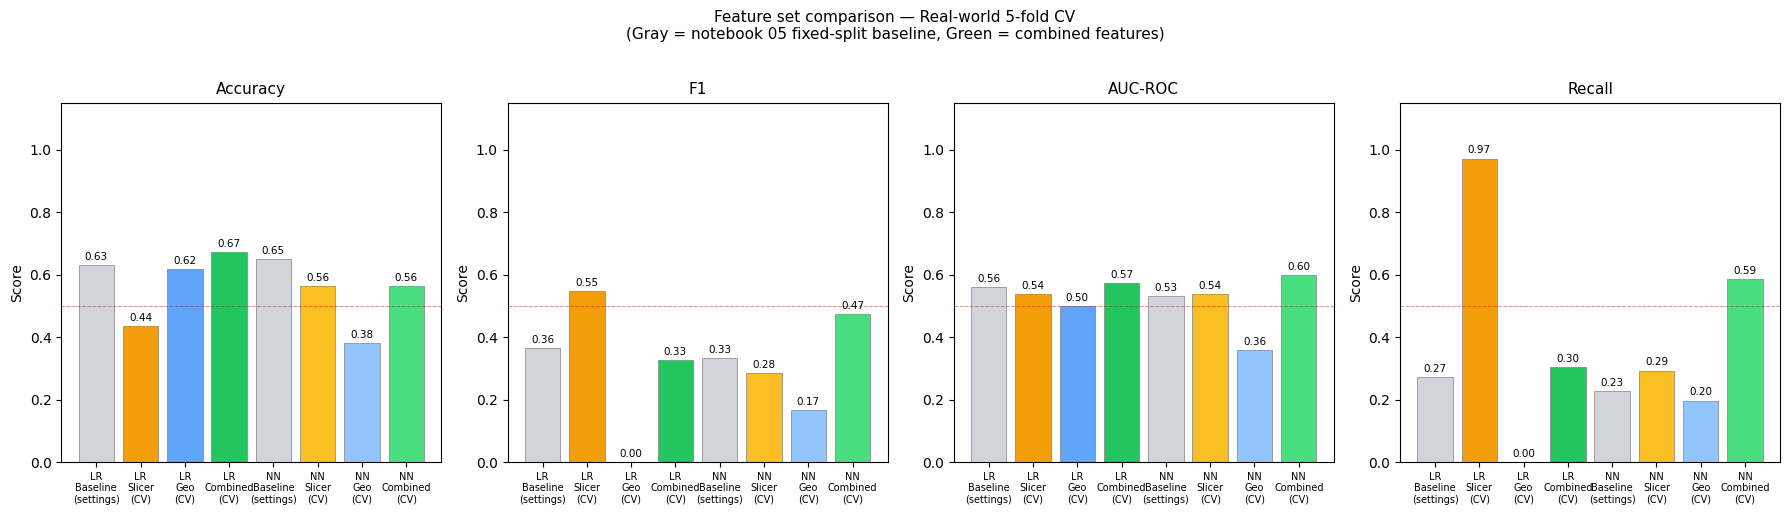

In [7]:
# Notebook 05 fixed-split baseline results
baseline = {
    "LR (settings only, fixed split)": {"accuracy": 0.6316, "f1": 0.3636, "auc": 0.5604, "recall": 0.2727},
    "NN (settings only, fixed split)": {"accuracy": 0.6491, "f1": 0.3333, "auc": 0.5312, "recall": 0.2273},
}

metrics_to_plot = ["accuracy", "f1", "auc", "recall"]
labels_plot = ["Accuracy", "F1", "AUC-ROC", "Recall"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

groups = {
    "LR\nBaseline\n(settings)": baseline["LR (settings only, fixed split)"],
    "LR\nSlicer\n(CV)":         mean_metrics(results["A_slicer_only"]["lr"]),
    "LR\nGeo\n(CV)":            mean_metrics(results["B_geometry_only"]["lr"]),
    "LR\nCombined\n(CV)":       mean_metrics(results["C_combined"]["lr"]),
    "NN\nBaseline\n(settings)": baseline["NN (settings only, fixed split)"],
    "NN\nSlicer\n(CV)":         mean_metrics(results["A_slicer_only"]["nn"]),
    "NN\nGeo\n(CV)":            mean_metrics(results["B_geometry_only"]["nn"]),
    "NN\nCombined\n(CV)":       mean_metrics(results["C_combined"]["nn"]),
}

colors = ["#d1d5db", "#f59e0b", "#60a5fa", "#22c55e",
          "#d1d5db", "#fbbf24", "#93c5fd", "#4ade80"]

for ax, metric, mlabel in zip(axes, metrics_to_plot, labels_plot):
    vals = [g.get(metric, 0) for g in groups.values()]
    bars = ax.bar(groups.keys(), vals, color=colors, edgecolor="gray", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_ylim(0, 1.15)
    ax.set_title(mlabel, fontsize=11)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", labelsize=7)
    ax.axhline(0.5, color="red", linewidth=0.7, linestyle="--", alpha=0.5)

plt.suptitle("Feature set comparison — Real-world 5-fold CV\n"
             "(Gray = notebook 05 fixed-split baseline, Green = combined features)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7. Geometry feature importance (LR weights on combined model)

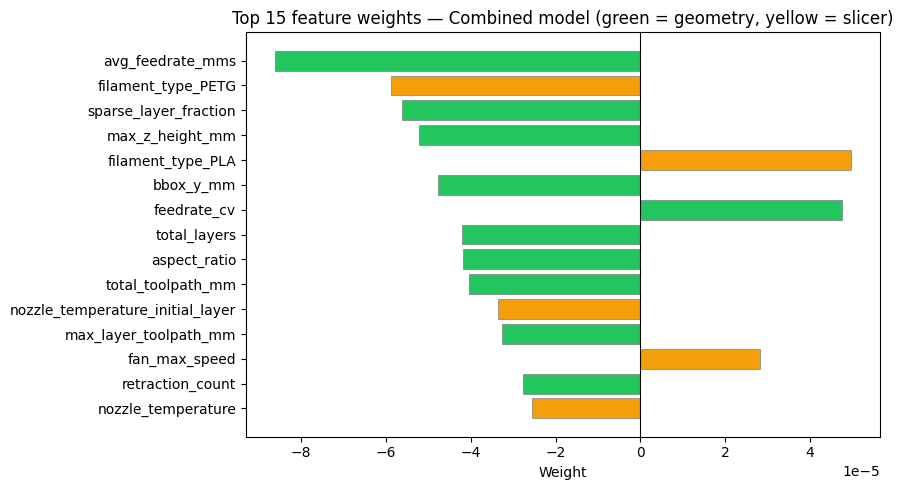

In [8]:
# Train one final LR on all 55 samples with combined features to inspect weights
geo_scaled, _ = scale_geo(X_geo_raw, X_geo_raw)
X_full = np.hstack([X_slicer, geo_scaled]).astype(np.float32)

final_lr = LogisticRegression(lr=0.001, n_iter=2000)
final_lr.fit(X_full, y, class_weight="balanced")

all_feature_names = feature_cols + GEO_COLS
abs_w   = np.abs(final_lr.weights)
order   = np.argsort(abs_w)[::-1][:15]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#22c55e" if i >= len(feature_cols) else "#f59e0b" for i in order]
ax.barh([all_feature_names[i] for i in order[::-1]],
        [final_lr.weights[i]  for i in order[::-1]],
        color=bar_colors[::-1], edgecolor="gray", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Weight")
ax.set_title("Top 15 feature weights — Combined model (green = geometry, yellow = slicer)")
plt.tight_layout()
plt.show()

## 8. Save combined model and results

In [9]:
import os

# Save final combined LR weights
combined_lr_path = os.path.join(MODELS_DIR, "combined_lr_weights.pkl")
final_lr.save(combined_lr_path)
print(f"Saved combined LR → {combined_lr_path}")

# Save CV summary
cv_summary = {}
for config_name, models in results.items():
    cv_summary[config_name] = {}
    for model_name, fold_list in models.items():
        m = mean_metrics(fold_list)
        cv_summary[config_name][model_name] = {k: round(v, 4) for k, v in m.items()}

out_path = os.path.join(MODELS_DIR, "geometry_cv_results.json")
with open(out_path, "w") as f:
    json.dump(cv_summary, f, indent=2)

print(f"Saved CV results → {out_path}")
print(json.dumps(cv_summary, indent=2))

Saved combined LR → ../models/combined_lr_weights.pkl
Saved CV results → ../models/geometry_cv_results.json
{
  "A_slicer_only": {
    "lr": {
      "accuracy": 0.4364,
      "precision": 0.3988,
      "recall": 0.9714,
      "f1": 0.5477,
      "auc": 0.5365
    },
    "nn": {
      "accuracy": 0.5636,
      "precision": 0.3778,
      "recall": 0.2929,
      "f1": 0.285,
      "auc": 0.5369
    }
  },
  "B_geometry_only": {
    "lr": {
      "accuracy": 0.6182,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "auc": 0.5
    },
    "nn": {
      "accuracy": 0.3818,
      "precision": 0.15,
      "recall": 0.1967,
      "f1": 0.1672,
      "auc": 0.3576
    }
  },
  "C_combined": {
    "lr": {
      "accuracy": 0.6727,
      "precision": 0.45,
      "recall": 0.3033,
      "f1": 0.3276,
      "auc": 0.5733
    },
    "nn": {
      "accuracy": 0.5636,
      "precision": 0.4333,
      "recall": 0.5862,
      "f1": 0.4735,
      "auc": 0.5994
    }
  }
}
